## Crypto Volatility Risk & Capital Allocation Analysis

**Objective:**  
Evaluate downside risk across major cryptocurrencies using volatility, drawdowns, and loss probabilities to inform capital allocation decisions.

**Assets analyzed:** Bitcoin (BTC), Ethereum (ETH), Tether (USDT)


# Business Question:
How risky are major cryptocurrencies relative to a stable asset, and how should capital exposure be adjusted under high volatility?

In [1]:
import pandas as pd
import requests
from datetime import datetime


In [7]:
coins = {
    "bitcoin": "BTC",
    "ethereum": "ETH",
    "tether": "USDT"
}

vs_currency = "usd"
days = 365


In [8]:
def fetch_price_data(coin_id):
    url = f"https://api.coingecko.com/api/v3/coins/{coin_id}/market_chart"
    params = {
        "vs_currency": vs_currency,
        "days": days
    }

    response = requests.get(url, params=params)
    data = response.json()

    # 🔍 DEBUG (temporary)
    if "prices" not in data:
        print(f"API response for {coin_id}: {data}")
        raise Exception(f"No prices returned for {coin_id}")

    prices = pd.DataFrame(data["prices"], columns=["timestamp", coin_id])
    prices["date"] = pd.to_datetime(prices["timestamp"], unit="ms").dt.date
    prices = prices.drop("timestamp", axis=1)

    return prices


In [9]:
price_dfs = []

for coin in coins:
    df_coin = fetch_price_data(coin)
    price_dfs.append(df_coin)

prices = price_dfs[0]
for df in price_dfs[1:]:
    prices = prices.merge(df, on="date", how="inner")

prices = prices.sort_values("date").reset_index(drop=True)
prices.head()


,bitcoin,date,ethereum,tether
0,98256.738768,2025-01-05,3660.378042,0.999930
1,98364.589466,2025-01-06,3635.854996,0.999741
2,102229.394532,2025-01-07,3687.144714,1.000674
3,96952.098868,2025-01-08,3380.021126,0.999875
4,95016.714410,2025-01-09,3325.130029,0.999467


In [10]:
prices.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 372 entries, 0 to 371
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   bitcoin   372 non-null    float64
 1   date      372 non-null    object 
 2   ethereum  372 non-null    float64
 3   tether    372 non-null    float64
dtypes: float64(3), object(1)
memory usage: 11.8+ KB


In [11]:
prices["date"] = pd.to_datetime(prices["date"])
prices = prices.set_index("date")
prices.head()


,bitcoin,ethereum,tether
date,,,
2025-01-05,98256.738768,3660.378042,0.999930
2025-01-06,98364.589466,3635.854996,0.999741
2025-01-07,102229.394532,3687.144714,1.000674
2025-01-08,96952.098868,3380.021126,0.999875
2025-01-09,95016.714410,3325.130029,0.999467


In [12]:
prices = prices.sort_index()
prices.info()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 372 entries, 2025-01-05 to 2026-01-04
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   bitcoin   372 non-null    float64
 1   ethereum  372 non-null    float64
 2   tether    372 non-null    float64
dtypes: float64(3)
memory usage: 11.6 KB


In [13]:
daily_returns = prices.pct_change()
daily_returns.head()


,bitcoin,ethereum,tether
date,,,
2025-01-05,NaN,NaN,NaN
2025-01-06,0.001098,-0.006700,-0.000189
2025-01-07,0.039291,0.014107,0.000933
2025-01-08,-0.051622,-0.083296,-0.000798
2025-01-09,-0.019962,-0.016240,-0.000408


In [14]:
daily_returns = daily_returns.dropna()
daily_returns.head()


,bitcoin,ethereum,tether
date,,,
2025-01-06,0.001098,-0.006700,-0.000189
2025-01-07,0.039291,0.014107,0.000933
2025-01-08,-0.051622,-0.083296,-0.000798
2025-01-09,-0.019962,-0.016240,-0.000408
2025-01-10,-0.027789,-0.031890,0.000493


In [15]:
weekly_returns = prices.resample("W").last().pct_change()
weekly_returns = weekly_returns.dropna()
weekly_returns.head()


,bitcoin,ethereum,tether
date,,,
2025-01-12,-0.037628,-0.102937,-0.000296
2025-01-19,0.103375,0.007768,-0.000740
2025-01-26,0.004423,0.003334,0.000938
2025-02-02,-0.039326,-0.058761,-0.000078
2025-02-09,-0.040890,-0.156618,0.000300


In [16]:
daily_returns.describe()


,bitcoin,ethereum,tether
count,371.000000,371.000000,371.000000
mean,0.000034,0.000336,-0.000001
std,0.021718,0.039020,0.000287
min,-0.086322,-0.146639,-0.001460
25%,-0.011170,-0.021429,-0.000141
50%,0.000000,0.000123,-0.000002
75%,0.011063,0.017467,0.000123
max,0.095997,0.213910,0.001327


In [17]:
rolling_vol_7d = daily_returns.rolling(window=7).std()
rolling_vol_30d = daily_returns.rolling(window=30).std()

rolling_vol_30d.tail()


,bitcoin,ethereum,tether
date,,,
2026-01-04,0.012926,0.023743,0.000211
2026-01-04,0.012950,0.023369,0.000212
2026-01-04,0.012205,0.020137,0.000213
2026-01-04,0.012127,0.020153,0.000213
2026-01-04,0.012082,0.019576,0.000214


In [18]:
rolling_vol_30d.describe()


,bitcoin,ethereum,tether
count,342.000000,342.000000,342.000000
mean,0.021074,0.038813,0.000256
std,0.006304,0.008358,0.000103
min,0.011359,0.019576,0.000125
25%,0.016541,0.032810,0.000176
50%,0.019692,0.036415,0.000230
75%,0.023664,0.047292,0.000303
max,0.037680,0.053918,0.000585


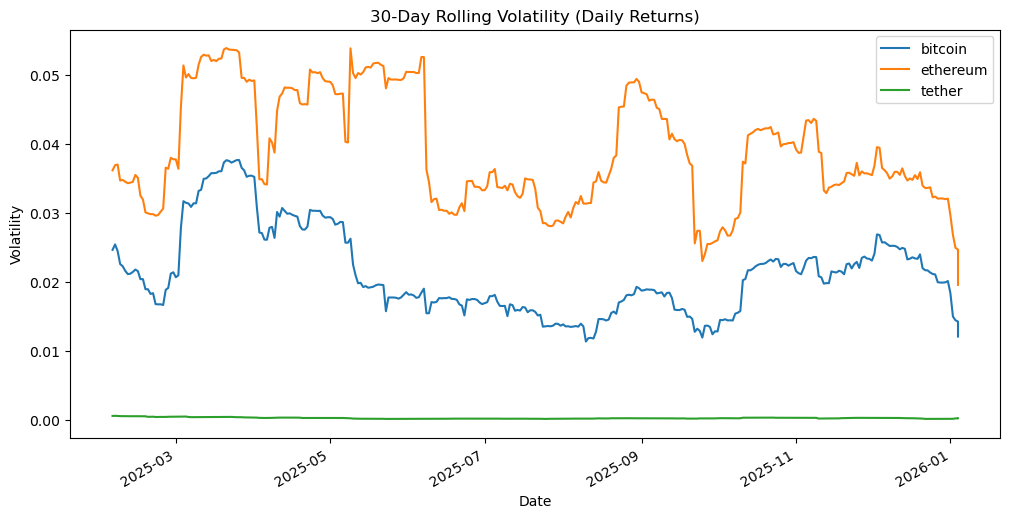

In [19]:
import matplotlib.pyplot as plt

rolling_vol_30d.plot(figsize=(12,6))
plt.title("30-Day Rolling Volatility (Daily Returns)")
plt.ylabel("Volatility")
plt.xlabel("Date")
plt.show()


## What is the worst loss an investor could have experienced?

In [21]:
cumulative_returns = (1 + daily_returns).cumprod()
cumulative_returns.head()


,bitcoin,ethereum,tether
date,,,
2025-01-06,1.001098,0.993300,0.999811
2025-01-07,1.040431,1.007313,1.000745
2025-01-08,0.986722,0.923408,0.999946
2025-01-09,0.967025,0.908412,0.999537
2025-01-10,0.940152,0.879443,1.000030


In [22]:
rolling_max = cumulative_returns.cummax()
drawdown = (cumulative_returns / rolling_max) - 1
drawdown.head()


,bitcoin,ethereum,tether
date,,,
2025-01-06,0.000000,0.000000,0.000000
2025-01-07,0.000000,0.000000,0.000000
2025-01-08,-0.051622,-0.083296,-0.000798
2025-01-09,-0.070554,-0.098183,-0.001206
2025-01-10,-0.096382,-0.126942,-0.000714


In [23]:
max_drawdown = drawdown.min()
max_drawdown


bitcoin    -0.321309
ethereum   -0.600948
tether     -0.003030
dtype: float64

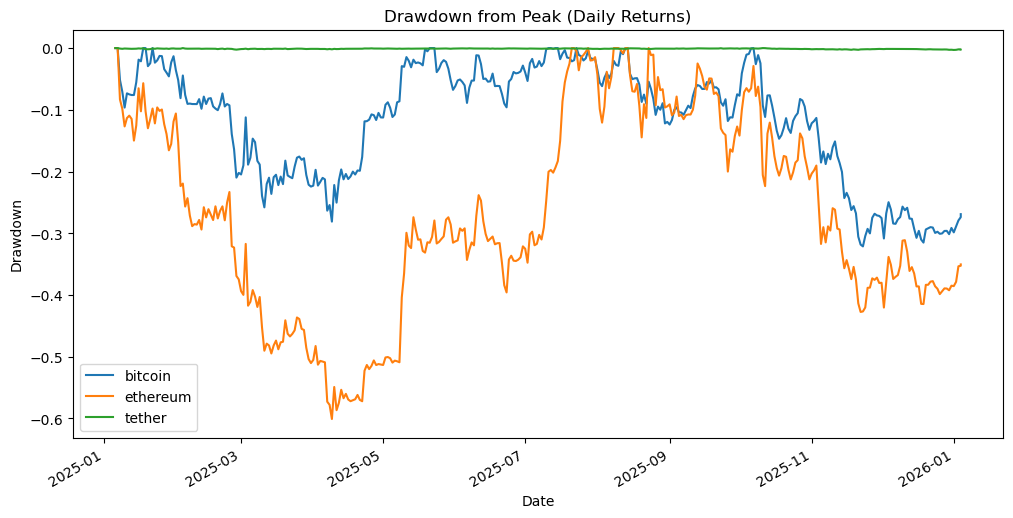

In [24]:
drawdown.plot(figsize=(12,6))
plt.title("Drawdown from Peak (Daily Returns)")
plt.ylabel("Drawdown")
plt.xlabel("Date")
plt.show()


## How often do these assets suffer large losses over short windows?

In [25]:
weekly_loss_prob = (weekly_returns < -0.10).mean()
weekly_loss_prob


bitcoin     0.038462
ethereum    0.173077
tether      0.000000
dtype: float64

In [26]:
monthly_returns = prices.resample("M").last().pct_change().dropna()
monthly_returns.head()


C:\Users\Pratibha\AppData\Local\Temp\ipykernel_12464\3110295621.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_returns = prices.resample("M").last().pct_change().dropna()


,bitcoin,ethereum,tether
date,,,
2025-02-28,-0.191564,-0.290288,-0.001041
2025-03-31,-0.027775,-0.216883,0.000738
2025-04-30,0.144494,-0.004634,0.000483
2025-05-31,0.103490,0.404850,-0.000024
2025-06-30,0.042166,-0.008639,-0.000125


### Loss Probability :

In [27]:
monthly_loss_prob = (monthly_returns < -0.20).mean()
monthly_loss_prob


bitcoin     0.00
ethereum    0.25
tether      0.00
dtype: float64

## SUMMARY TABLE :

In [28]:
risk_summary = pd.DataFrame({
    "Max Drawdown": max_drawdown,
    "Weekly Loss Prob (>10%)": weekly_loss_prob,
    "Monthly Loss Prob (>20%)": monthly_loss_prob
})

risk_summary


,Max Drawdown,Weekly Loss Prob (>10%),Monthly Loss Prob (>20%)
bitcoin,-0.321309,0.038462,0.00
ethereum,-0.600948,0.173077,0.25
tether,-0.003030,0.000000,0.00


## FINAL DECISION TABLE & CAPITAL ALLOCATION GUIDANCE

In [29]:
def assign_risk_label(row):
    if row["Max Drawdown"] < -0.5 or row["Monthly Loss Prob (>20%)"] > 0.2:
        return "Very High"
    elif row["Max Drawdown"] < -0.3 or row["Weekly Loss Prob (>10%)"] > 0.1:
        return "High"
    elif row["Max Drawdown"] < -0.1:
        return "Medium"
    else:
        return "Low"


In [30]:
risk_summary["Risk Level"] = risk_summary.apply(assign_risk_label, axis=1)
risk_summary


,Max Drawdown,Weekly Loss Prob (>10%),Monthly Loss Prob (>20%),Risk Level
bitcoin,-0.321309,0.038462,0.00,High
ethereum,-0.600948,0.173077,0.25,Very High
tether,-0.003030,0.000000,0.00,Low


In [31]:
allocation_guidance = {
    "Very High": "Limit exposure; suitable only for high-risk tolerance portfolios",
    "High": "Moderate exposure with strict risk limits",
    "Medium": "Balanced exposure acceptable",
    "Low": "Safe baseline or capital preservation"
}

risk_summary["Allocation Guidance"] = risk_summary["Risk Level"].map(allocation_guidance)
risk_summary


,Max Drawdown,Weekly Loss Prob (>10%),Monthly Loss Prob (>20%),Risk Level,Allocation Guidance
bitcoin,-0.321309,0.038462,0.00,High,Moderate exposure with strict risk limits
ethereum,-0.600948,0.173077,0.25,Very High,Limit exposure; suitable only for high-risk to...
tether,-0.003030,0.000000,0.00,Low,Safe baseline or capital preservation
